<a href="https://colab.research.google.com/github/jjianhhao/SC3021/blob/main/SC3021_HDB_Resale_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
# All relevant imports for the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime
import sqlite3
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# How do different Housing Development Board (HDB) flat to amenities affect Singapore HDB flat resale prices?
---

**Team Members:** Jian Hao, Ignatius, Ajitesh

**Lab Group:** SDAC, Group 9

---

# 1. Problem Formulation

## Background

Over 80% of Singapore residents live in HDB flats, making the resale market one of the most active property markets in the country. In recent years, we've seen resale prices climb steadily — even hitting record highs in 2023 — despite the government rolling out multiple rounds of cooling measures. At the same time, interest rates (SORA) jumped from near-zero during COVID to over 3.5%, directly increasing monthly mortgage payments for buyers.

As NTU students who will likely be entering the housing market in the next few years, we wanted to understand: **what actually drives HDB resale prices?**

## Problem Definition

Our project investigates the following question:

> **How do different Housing Development Board (HDB) flat attributes, proximity to amenities, government cooling measures, and macroeconomic conditions (interest rates) affect Singapore HDB resale flat prices?**

This is a **regression problem** at its core — we want to understand and eventually predict HDB resale prices based on a combination of:

- **Flat-level features**: floor area, storey range, flat type, remaining lease, flat age
- **Location-based features**: distance to nearest MRT station, distance to nearest shopping mall
- **Macroeconomic features**: prevailing SORA interest rates at the time of transaction
- **Policy-based features**: whether the transaction occurred before or after specific government cooling measures

## Why This Matters

This analysis is relevant to multiple stakeholders:

1. **Prospective homebuyers** — understanding what factors contribute most to price can help buyers prioritise what to look for (e.g., proximity to MRT vs. flat size vs. timing the market around policy changes)
2. **Policy makers** — evaluating whether cooling measures actually achieve their intended effect of moderating prices
3. **Urban planners** — quantifying the price premium associated with transport and retail accessibility

## Scope

- **Time period**: January 2017 to December 2024
- **Geography**: All 26 HDB towns across Singapore
- **Transaction type**: Resale transactions only (excludes BTO and rental)
- **Target variable**: `resale_price` (continuous, in SGD)

# 2. Requirement Analysis

## What Do We Need to Answer Our Question?

To investigate what drives HDB resale prices, we need to bring together multiple types of data and connect them meaningfully. Here's what we identified:

### Data Requirements

| Requirement | What We Need | Why |
|------------|-------------|-----|
| Transaction data | HDB resale records with price, flat type, floor area, lease info | This is our **target variable** and contains core flat-level features |
| Transport accessibility | MRT/LRT station locations with coordinates | To compute **distance to nearest MRT** for each flat — tests whether transport access affects price |
| Retail accessibility | Shopping mall locations with coordinates | To compute **distance to nearest mall** — tests whether retail proximity affects price |
| Interest rates | Historical SORA rates (daily/monthly) | To capture the **macroeconomic environment** at the time of each transaction |
| Policy timeline | Dates and details of government cooling measures | To create **before/after policy indicators** for measuring policy impact on prices |
| Geocoding service | API to convert HDB block addresses to lat/long coordinates | Required to calculate distances — HDB data only has street addresses, not coordinates |

### Analytical Requirements

To properly test our hypotheses, we need the following types of analysis:

**Descriptive Analysis** — Understand the basic distributions: how are prices spread across towns, flat types, and time periods? Are there obvious trends or outliers?

**Correlation & Diagnostic Analysis** — Measure relationships between price and our features (distance to MRT, SORA rates, flat attributes). We'll use correlation matrices and scatter plots to identify which factors have the strongest associations.

**Hypothesis Testing** — Statistical tests to evaluate specific claims:
- t-tests or Mann-Whitney U tests to compare prices before/after cooling measures
- Correlation significance tests for SORA vs. price relationships
- Comparison of prices within 500m of MRT vs. further away

**Predictive Modelling** — Build regression models (starting with Linear Regression, then potentially Random Forest) to predict resale prices and measure feature importance. Target: R² > 0.7.

### Technical Requirements

- **Geocoding**: We need to convert ~10,000 unique HDB addresses to coordinates using the OneMap API (rate limit: 250 requests/min, so we need batching and caching)
- **Distance computation**: Haversine formula to calculate great-circle distances between HDB flats and amenities
- **Data integration**: Merging 5 datasets on common keys (month/year for temporal data, coordinates for spatial data)
- **Storage**: SQLite database for the integrated dataset to enable SQL-based queries

### Key Assumptions

1. Resale price is primarily influenced by flat attributes, location, macroeconomic conditions, and policy interventions
2. Straight-line (Haversine) distance is a reasonable proxy for actual walking distance to amenities
3. Monthly average SORA is representative of the interest rate environment at the time of transaction
4. The effects of cooling measures can be observed within 3-6 months of implementation

## Hypothesis/analysis goal (Ask)

## Problem Statement

The Singapore HDB resale market is influenced by multiple complex factors including flat attributes (square feet, floor etc.), government cooling measures, macroeconomic conditions (interest rates), and locational attributes (proximity to amenities). Understanding how these factors interact to influence resale prices is crucial for:

1. **Home buyers** seeking to make informed purchasing decisions
2. **Policy makers** evaluating the effectiveness of housing policies
3. **Urban planners** understanding the value of amenity accessibility

## Research Questions

We aim to answer the following questions:

1. **Flat Attributes** Do flat attributes lead to changes in flat prices?
2. **Policy Impact**: Do HDB cooling measures lead to measurable changes in resale prices following their implementation?
3. **Interest Rate Effect**: How do SORA (Singapore Overnight Rate Average) fluctuations correlate with resale price trends?
4. **Amenity Proximity**: Does proximity to MRT stations and shopping malls significantly correlate with higher resale prices?
5. **Predictive Modeling**: Can we build a model to predict HDB resale prices based on these factors? (Linear Regression / Random Forest)

## Hypotheses

- **H1**: Implementation of cooling measures (e.g., increased ABSD, tightened LTV) leads to a decrease in median resale prices within 3-6 months.
- **H2**: Higher SORA rates negatively correlate with resale prices due to increased mortgage costs reducing buyer affordability.
- **H3**: HDB flats within 500m of MRT stations command a price premium of at least 5% compared to those further away.
- **H4**: A combination of flat characteristics, location features, and macroeconomic indicators can predict resale prices with R² > 0.7.

## Analysis Types Required

| Analysis Type | Application |
|--------------|-------------|
| **Descriptive** | Price distributions by town, flat type, time period |
| **Diagnostic** | Correlation analysis between prices and influencing factors |
| **Predictive** | Regression model for price prediction |
| **Prescriptive** | Recommendations for buyers based on findings |

## Quality Metrics

- **Prediction Model**: R² score > 0.7, RMSE < $50,000

# Data Source Identification and Exploration (Prepare)


## Overview of Data Sources

We utilise **5 data sources** to analyse HDB resale prices:

| ID | Dataset | Source | Format | Records | Purpose |
|----|---------|--------|--------|---------|--------|
| DS1 | HDB Resale Flat Prices | Kaggle / data.gov.sg | CSV | ~181,000 | Main dataset - target variable |
| DS2 | MRT/LRT Station Coordinates | Kaggle | CSV | 157 | Transport accessibility analysis |
| DS3 | Singapore Malls POI | Kaggle | CSV | 249 | Retail amenity proximity |
| DS4 | SORA Interest Rates | MAS | CSV | ~2,000 | Macroeconomic factor |
| DS5 | HDB Cooling Measures | Manual compilation | CSV | 9 | Policy impact analysis |
| API | OneMap Geocoding | OneMap.sg | REST API | - | Address to coordinates conversion |

## DS1: HDB Resale Flat Prices (2017-2024)

**Source**: [Kaggle - Singapore Resale Flat Prices](https://www.kaggle.com/datasets/darrylljk/singapore-hdb-resale-flat-prices-2017-2024) / [data.gov.sg](https://data.gov.sg/datasets/d_8b84c4ee58e3cfc0ece0d773c8ca6abc/view)

**Description**: Transaction records of HDB resale flats from January 2017 onwards, including flat characteristics and transaction prices, offering relevant information for our analysis. It includes the street name and block number, which are at an appropriate level of granularity to combine with the other datasets for appropriate geospatial analysis. The following code imports the data into a DataFrame and displays the head, giving an illustration of the data.

In [127]:
# Load DS1: HDB Resale Flat Prices
df1 = pd.read_csv('data/sg-resale-flat-prices-2017-onwards.csv')

print("DS1: HDB RESALE FLAT PRICES (2017-2024)")
df1.head()

DS1: HDB RESALE FLAT PRICES (2017-2024)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [128]:
# DS1: Data types and missing values
print("DATA TYPES AND MISSING VALUES")
df1.info()

DATA TYPES AND MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181262 entries, 0 to 181261
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                181262 non-null  object 
 1   town                 181262 non-null  object 
 2   flat_type            181262 non-null  object 
 3   block                181262 non-null  object 
 4   street_name          181262 non-null  object 
 5   storey_range         181262 non-null  object 
 6   floor_area_sqm       181262 non-null  float64
 7   flat_model           181262 non-null  object 
 8   lease_commence_date  181262 non-null  int64  
 9   remaining_lease      181262 non-null  object 
 10  resale_price         181262 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 15.2+ MB


From an initial inspection of the dataset, several variables require transformation before meaningful analysis can be performed. The remaining_lease field is stored as a textual description rather than a numeric value, which limits its direct use in statistical analysis and modeling. As lease duration is an important quantitative factor, this variable needs to be parsed and converted into numeric years.

In addition, the month variable is currently represented as a YYYY-MM format, which prevents it from being used for time-based operations such as sorting, filtering, or merging with external temporal datasets. Converting this field into a proper datetime format ensures consistency and enables time-series analysis.

The `block` column itself also cannot function alone as there many blocks with the same number but different locations. Therefore, to make the column meaningful, we have decided to combine the `block` and `address` column to make the data more unique.

Finally, while location-related attributes are present, they are distributed across multiple columns (street_name, block, town). To support geocoding and spatial analysis, these components need to be combined into a single address field that can be interpreted by geocoding services.

In [129]:
# DS1: Statistical summary
print("STATISTICAL SUMMARY (Numerical Columns)")
df1.describe()

STATISTICAL SUMMARY (Numerical Columns)


,floor_area_sqm,lease_commence_date,resale_price
count,181262.000000,181262.000000,1.812620e+05
mean,97.152903,1996.013842,4.978643e+05
std,24.025926,14.041087,1.726320e+05
min,31.000000,1966.000000,1.400000e+05
25%,82.000000,1985.000000,3.700000e+05
50%,93.000000,1996.000000,4.680000e+05
75%,112.000000,2010.000000,5.920000e+05
max,249.000000,2020.000000,1.588000e+06


From the looks of the statistical summary of the numerical columns in our dataset, it is quite clear that there are some anomalies (or rather outliers). The overall dataset tend to be right skewed as the max values far exceeds the mean and the standard deviation. This is however not surprising as there are some HDB flats which are of a higher tier which can inflate the prices. Moving forward, we decided to continue the dataset exploration to see if we should keep these values.

In [130]:
# DS1: Categorical column distributions
print("CATEGORICAL DISTRIBUTIONS")

categorical_cols = ['town', 'flat_type', 'flat_model', 'storey_range', 'street_name']

for col in categorical_cols:
    print(f"\n{col.upper()} ({df1[col].nunique()} unique values):")
    print(df1[col].value_counts().head(5))
    print(df1[col].value_counts().tail(10))

CATEGORICAL DISTRIBUTIONS

TOWN (26 unique values):
town
SENGKANG     14993
PUNGGOL      13448
WOODLANDS    12847
YISHUN       12429
TAMPINES     12139
Name: count, dtype: int64
town
QUEENSTOWN       5002
SEMBAWANG        4957
GEYLANG          4428
CLEMENTI         4070
JURONG EAST      3725
SERANGOON        3311
BISHAN           3284
CENTRAL AREA     1463
MARINE PARADE    1118
BUKIT TIMAH       456
Name: count, dtype: int64

FLAT_TYPE (7 unique values):
flat_type
4 ROOM       76457
5 ROOM       45059
3 ROOM       42908
EXECUTIVE    13474
2 ROOM        3218
Name: count, dtype: int64
flat_type
4 ROOM              76457
5 ROOM              45059
3 ROOM              42908
EXECUTIVE           13474
2 ROOM               3218
MULTI-GENERATION       78
1 ROOM                 68
Name: count, dtype: int64

FLAT_MODEL (21 unique values):
flat_model
Model A              63164
Improved             44622
New Generation       22514
Premium Apartment    20466
Simplified            6968
Name: count, d

From the number of unique values of the dataset, it is clear that there are some categories that appear rarely especially in the `flat_model` and`storey_range` column with a huge variance in the count of values. Since the categories with such a low count cannot provide any meaningful insights, we have to clear them for a more meaningful analysis. This is natural as higher end HDB flats tend to be on higher floors and are definitely lower in quantity which might also explain the right skewed distribution of the prices.

In [131]:
# DS1: Finding if there are duplicated values

df1.duplicated().sum()

np.int64(288)

There are 288 duplicated values which require cleaning.

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64


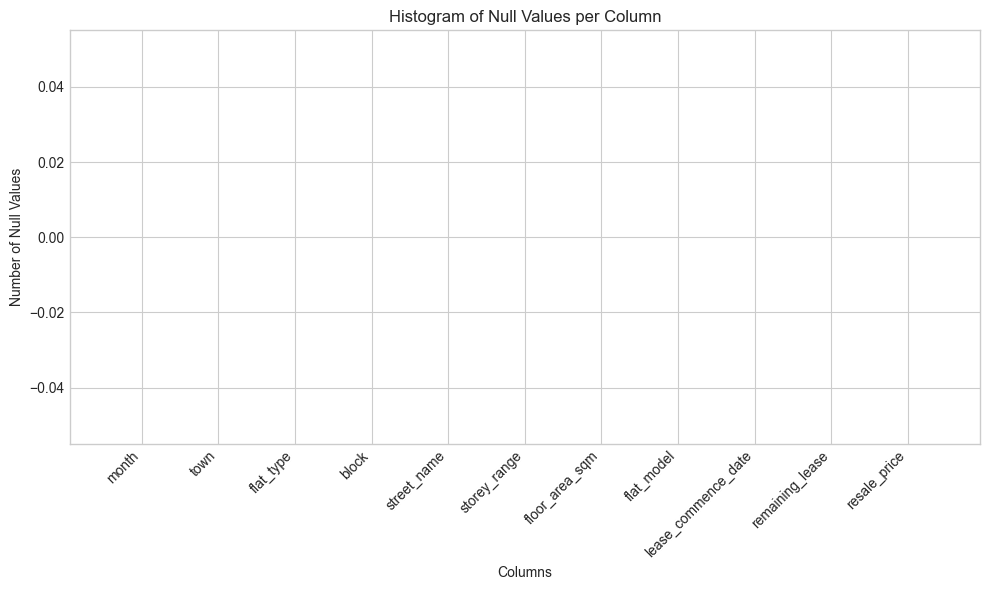

In [132]:
null_counts = df1.isnull().sum()
print(null_counts)

plt.figure(figsize=(10, 6))
plt.bar(null_counts.index, null_counts.values)
plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.title("Histogram of Null Values per Column")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


### DS1 Assessment:

*   The dataset satisfies our requirement for the task at hand as it is quite comprehensive in the coverage of many flat characteristics and resale price. It works well with the other datasets to be used with minimal cleaning needed.
*   The interpretability of the dataset is high with attributes being easy to understand.
* This dataset is obtained from Kaggle which is well used in the data science community. The reputation of the dataset is good as this Kaggle dataset is taken from data.gov.sg, an official government dataset website.

This dataset ideally fits our data requirements and hence we will be using it.

###Conclusion:

**Data Quality**:
- No missing values across all 181,262 records
- 288 duplicated rows

**Key Observations**:
- Price range: $140,000 - $1,588,000 (median: $468,000) (Right Skewed)
- Floor area: 31-249 sqm (median: 93 sqm)
- 26 unique towns, 7 flat types, 21 flat models

**Required Transformations**:
1. Parse `remaining_lease` to numeric years
2. Convert `month` to datetime
3. Create `address` column for geocoding
4. Combine `block` and `address` columns

**Required Cleaning**
- Remove duplicated rows
- Remove outliers

DS1 provides much information of the flat characteristics and resale price

## DS2: MRT/LRT Station Coordinates

**Source**: [Kaggle - Singapore MRT & LRT Stations with Coordinates
](https://www.kaggle.com/datasets/shengjunlim/singapore-mrt-lrt-stations-with-coordinates?resource=download)

**Description**: Geographic coordinates (latitude, longitude) of all MRT and LRT stations in Singapore. It has four main columns `OBJECTID`, `station_name`, `station_no`, `geometry`, `lat`, `lng`.

**Main Purpose**: Calculate distance from each HDB flat to nearest train station as distance to nearest train station is a factor in HDB flat prices.

In [133]:
# Load DS2: MRT/LRT Station Coordinates
df2 = pd.read_csv('data/MRT Stations.csv', index_col = 0)

print("DS2: MRT/LRT STATION COORDINATES")
df2.head(10)

DS2: MRT/LRT STATION COORDINATES


,OBJECTID,station_name,station_no,geometry,lat,lng
0,1,EUNOS MRT STATION,EW7,POINT (103.9032524667383 1.319778951553637),1.319779,103.903252
1,2,CHINESE GARDEN MRT STATION,EW25,POINT (103.7325967380734 1.342352820874744),1.342353,103.732597
2,3,KHATIB MRT STATION,NS14,POINT (103.8329799077383 1.417383370153547),1.417383,103.832980
3,4,KRANJI MRT STATION,NS7,POINT (103.7621654109002 1.425177698770448),1.425178,103.762165
4,5,REDHILL MRT STATION,EW18,POINT (103.816816670149 1.289562726402453),1.289563,103.816817
5,6,YEW TEE MRT STATION,NS5,POINT (103.7474051141379 1.397535017793412),1.397535,103.747405
6,7,PIONEER MRT STATION,EW28,POINT (103.6973215129361 1.337586882204749),1.337587,103.697322
7,8,COMMONWEALTH MRT STATION,EW20,POINT (103.798304515629 1.30243873532717),1.302439,103.798305
8,9,PAYA LEBAR MRT STATION,EW8/CC9,POINT (103.8930603552516 1.318112082295278),1.318112,103.893060
9,10,SIMEI MRT STATION,EW3,POINT (103.9533716941757 1.343202894930727),1.343203,103.953372


From the head of the dataset, we can see that some columns are not relevant to us and can be dropped. For example, we only need the `station_name` along with its latitude and longitude for subsequent geospatial analysis

In [134]:
#DS2 Dataset information

df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171 entries, 0 to 170
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OBJECTID      171 non-null    int64  
 1   station_name  171 non-null    object 
 2   station_no    171 non-null    object 
 3   geometry      171 non-null    object 
 4   lat           171 non-null    float64
 5   lng           171 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.4+ KB


From the information of this dataset, we can see that there are 171 entries with all of them not being null values. The data types of the dataset is also consistent with `OBJECTID` being `int`, `lat` and `lng` being `float` and the rest being `string`. Therefore, no transformation is needed for this dataset.

In [135]:
# DS2: Data quality check
print("DS2 DATA QUALITY CHECK")
print(f"\nMissing values: {df2.isnull().sum().sum()}")
print(f"Duplicate stations: {df2.duplicated(subset=['station_name']).sum()}")
print(f"\nCoordinate ranges:")
print(f"  lat:  {df2['lat'].min():.4f} to {df2['lat'].max():.4f}")
print(f"  lng: {df2['lng'].min():.4f} to {df2['lng'].max():.4f}")

# Verify coordinates are within Singapore bounds
sg_bounds = {'lat_min': 1.15, 'lat_max': 1.47, 'lng_min': 103.6, 'lng_max': 104.1}
valid_coords = (
    (df2['lat'] >= sg_bounds['lat_min']) & (df2['lat'] <= sg_bounds['lat_max']) &
    (df2['lng'] >= sg_bounds['lng_min']) & (df2['lng'] <= sg_bounds['lng_max'])
).all()
print(f'Valid coordinates: ',{valid_coords})

DS2 DATA QUALITY CHECK

Missing values: 0
Duplicate stations: 0

Coordinate ranges:
  lat:  1.2655 to 1.4491
  lng: 103.6369 to 103.9884
Valid coordinates:  {np.True_}


From the data quality checks, we can see that there are no missing or duplicate values. Each coordinate from this dataset also falls within Singapore. Hence, there are minimal data errors.

### DS2 Assessment

*   This dataset satisfies our requirement for the its purpose which is to provide coordinates of amenities for geospatial analysis.
*   The interpretability of the dataset is high, given that it limits to few essential attributes with clear semantics. This makes misinterpretation and misuse highly during analysis highly unlikely.
* However, the reputation of the dataset remains unclear. The source of this dataset is unclear and there is no updates on new stations. According to [SGTrain.com](https://www.sgtrains.com/network-figures.html), there are currently 185 train stations - meaning that there are 14 unreported stations in this dataset. This is bound to happen as new MRT and LRT stations are constantly being build, hence without frequent updates, not all stations are reported.

Despite the moderate reputation, the dataset ideally fits our data requirements so we eventually opted to use it. We are however aware that potential errors in the data can affect the accuracy of the trained model.

## Conclusion

**Data Quality**:
- 171 stations with complete coordinate data
- All coordinates within valid Singapore bounds
- Mix of MRT and LRT stations

**Limitations**:
- May not include newest stations (e.g., some Thomson-East Coast Line stations)
- No opening date information

**Usage**: Will calculate Haversine distance from each HDB flat to all stations, then take minimum.

## DS3: Singapore Malls POI

**Source**: [Kaggle - Singapore Malls POI](https://www.kaggle.com/datasets/sunnysharma432/singapore-malls-pois)

**Description**: Point of Interest (POI) data for shopping malls in Singapore.

**Purpose**: Calculate distance from each HDB flat to nearest shopping mall.

In [136]:
# Load DS3: Singapore Malls POI
df3 = pd.read_csv('data/singapore_malls_pois.csv')

print("DS3: SINGAPORE MALLS POI")
df3.head()

DS3: SINGAPORE MALLS POI


,name,category,lat,lon,brand,address,website,phone
0,The Star Vista,mall,1.308002,103.788382,NaN,Vista Exchange Green,NaN,NaN
1,Bencoolen Underground Mall,mall,1.298181,103.849647,NaN,NaN,NaN,NaN
2,Bencoolen Underground Mall,mall,1.299224,103.850755,NaN,NaN,NaN,NaN
3,Katong V,mall,1.303133,103.903231,NaN,Marine Parade Road,NaN,NaN
4,The Poiz Centre,mall,1.331436,103.868571,NaN,Upper Serangoon Road,https://thepoizcentre.com.sg/,NaN


The dataset consists of 8 columns: `name`, `category`, `lat`, `lon`, `brand`, `address`, `website` and `phone`. Since the longitude column for our other datasets has always been labelled as `lng`, we will change the column name to `lng` for better comparison and joining.

We can also see that there are many null values and hence we have to explore the specific number of null values for each column.

In [137]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      235 non-null    object 
 1   category  249 non-null    object 
 2   lat       249 non-null    float64
 3   lon       249 non-null    float64
 4   brand     0 non-null      float64
 5   address   205 non-null    object 
 6   website   72 non-null     object 
 7   phone     41 non-null     object 
dtypes: float64(3), object(5)
memory usage: 15.7+ KB


From the information from the dataset, there are 249 entries. Since we are only concerned with the latitude and longitude columns, we can see that both columns have exactly 249 entries which means that the data that we need is complete. Other attributes like brand, address, website and phone are not needed and we can drop those columns.



In [138]:
# DS3: Data quality check
print("DS3 DATA QUALITY CHECK")
print(df3.isnull().sum())
print(f"\nDuplicate mall names: {df3.duplicated(subset=['name']).sum()}")
print(f"Unique malls: {df3['name'].nunique()}")

# Check coordinate validity
valid_coords = (
    (df3['lat'] >= 1.15) & (df3['lat'] <= 1.47) &
    (df3['lon'] >= 103.6) & (df3['lon'] <= 104.1)
).all()
print(f"\nAll coordinates within Singapore bounds: {valid_coords}")

DS3 DATA QUALITY CHECK
name         14
category      0
lat           0
lon           0
brand       249
address      44
website     177
phone       208
dtype: int64

Duplicate mall names: 29
Unique malls: 219

All coordinates within Singapore bounds: True


We test the integrity of the data here using the coordinates columns. After checking, the data is mostly accurate with data points all being within Singapore.

### DS3 Assessment

Like the previous dataset, the dataset has a reliability issue as no source of data is being mentioned. Hence this may affect the reliability of the results.

The reason for the sheer amount of null values can be attributed to the fact that not all malls have a website and a phone number. The dataset lacks much information in other aspects but since the columns that we are using is present and truthful, we choose to continue using this dataset.

**Data Quality**:
- 249 mall entries, but 29 duplicates
- Some missing addresses (120 nulls) - acceptable since we have coordinates
- `brand`, `website`, `phone` columns not needed - will drop

**Required Transformations**:
1. Remove duplicate entries
2. Drop unnecessary columns
3. Rename `lon` to `lng` for consistency with DS2

## DS4: SORA Interest Rates (2017-2026)

**Source**: [Monetary Authority of Singapore (MAS)](https://eservices.mas.gov.sg/statistics/msb/ExchangeRates.aspx)

**Description**: Singapore Overnight Rate Average (SORA) - the benchmark interest rate used for HDB loans since 2020.

**Purpose**: Analyze correlation between interest rates and resale prices (macroeconomic factor).

In [139]:
# Load DS4: SORA Interest Rates
df4 = pd.read_csv('data/Domestic Interest Rates.csv')

print("DS4: SORA INTEREST RATES (2017-2026)")
print(f"\nDate Range: {df4['Date'].iloc[0]} to {df4['Date'].iloc[-1]}")
df4.head()

DS4: SORA INTEREST RATES (2017-2026)

Date Range: 3/1/2017 to 23/1/2026


,Date,SORA,Compound SORA - 3 month,Compound SORA - 6 month
0,3/1/2017,0.2354,0.1478,0.1400
1,4/1/2017,0.1257,0.1488,0.1399
2,5/1/2017,0.1040,0.1494,0.1399
3,6/1/2017,0.1122,0.1498,0.1403
4,9/1/2017,0.0523,0.1490,0.1402


This dataset consists of 4 columns: `Date`, `SORA`, `Compound SORA - 3 month` and `Compount SORA - 6 month`.

From the head of the dataset, all values seem valid and no anomalies can be seen. However, more data exploration must be done to confirm that this dataset can be used effectively.

In [140]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2275 entries, 0 to 2274
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2275 non-null   object 
 1   SORA                     2275 non-null   float64
 2   Compound SORA - 3 month  2275 non-null   float64
 3   Compound SORA - 6 month  2275 non-null   float64
dtypes: float64(3), object(1)
memory usage: 71.2+ KB


From the information of the dataset, we can see that there are 2275 entries with all columns having no null values.

The data type of the columns are also consistent with `Date` being in a `String` format and the other `SORA` columns having a `float` data type.

In [141]:
df4.duplicated().sum()

np.int64(0)

There are no duplicates in this dataset. Hence, this dataset is relatively clean and can be used for training.

In [142]:
# DS4: Statistical summary
print("DS4 STATISTICAL SUMMARY")
df4.describe()

DS4 STATISTICAL SUMMARY


,SORA,Compound SORA - 3 month,Compound SORA - 6 month
count,2275.000000,2275.000000,2275.000000
mean,1.537003,1.548021,1.537608
std,1.288747,1.275300,1.277059
min,0.009300,0.069600,0.094500
25%,0.310600,0.338200,0.345100
50%,1.243100,1.229500,1.251400
75%,2.600250,2.748400,2.667350
max,4.391600,3.761100,3.748000


From the statistical summary, values fall in a reasonable range showing that there are no extreme values and outliers.

### DS4 Assessment

As this dataset is from the MAS, a government website, this dataset is reliable.

As the dataset provides many instances and different types of interest rates, there is a large breadth of data that we can use for analysis. Therefore with the clean nature of this dataset and the vast amount of data that we can use, we choose to proceed with this dataset.

**Data Quality**: Good
- Daily SORA rates from 2017 onwards
- Includes 3-month and 6-month compound rates

**Key Observations**:
- SORA ranged from near-zero (2020-2021) to over 3.5% (2023-2024)
- Clear correlation expected with housing affordability

**Required Transformations**:
1. Parse `Date` to datetime
2. Aggregate to monthly average for merging with DS1
3. Create `year_month` column for joining

## DS5: HDB Cooling Measures (2017-2024)

**Source**: Manual compilation from HDB, MAS, and government announcements

**Description**: Timeline of government housing policies and cooling measures that may impact resale prices.

**Purpose**: Analyze price trends before/after policy implementations.

In [143]:
# DS5: HDB Cooling Measures (manually compiled)
cooling_measures = {
    'date': [
        '2017-03-10', '2018-07-06', '2019-09-20', '2021-09-15',
        '2021-12-16', '2022-09-30', '2023-04-26', '2024-02-15', '2024-08-20'
    ],
    'measure_name': [
        'Enhanced CPF Housing Grant',
        'Tightened Loan-to-Value (LTV) Limits',
        'CPF Housing Grant Changes',
        'Wait-Out Period for Private Property Owners',
        'LTV Limits Tightened Further',
        'ABSD Rate Increase',
        'Prime Location Public Housing (PLH) Model',
        'Enhanced CPF Housing Grant Increased',
        'Fresh Start Housing Scheme'
    ],
    'category': [
        'Grant', 'Financial', 'Grant', 'Eligibility',
        'Financial', 'Financial', 'Eligibility', 'Grant', 'Eligibility'
    ],
    'severity': [
        'Medium', 'Medium', 'Low', 'High',
        'High', 'High', 'High', 'Low', 'Low'
    ],
    'expected_impact': [
        'Positive', 'Cooling', 'Mixed', 'Cooling',
        'Cooling', 'Cooling', 'Cooling', 'Positive', 'Neutral'
    ],
    'description': [
        'EHG introduced, up to $80,000 for families',
        'LTV reduced from 90% to 85% for loans >25 years',
        'Adjustments to income ceilings and grant amounts',
        '15-month wait-out period for private property sellers',
        'HDB loan LTV capped at 85%, bank loan at 75%',
        'ABSD for 2nd property: 17%, PRs 1st: 5%',
        '10-year MOP, 6% subsidy clawback for prime areas',
        'Maximum EHG increased to $120,000',
        'Shorter wait time for divorced/separated singles'
    ]
}

df5 = pd.DataFrame(cooling_measures)
df5['date'] = pd.to_datetime(df5['date'])

print("DS5: HDB COOLING MEASURES (2017-2024)")
print(f"\nTotal measures: {len(df5)}")
print(f"\nBy Category: {df5['category'].value_counts().to_dict()}")
print(f"By Severity: {df5['severity'].value_counts().to_dict()}")
print(f"By Expected Impact: {df5['expected_impact'].value_counts().to_dict()}")

df5

DS5: HDB COOLING MEASURES (2017-2024)

Total measures: 9

By Category: {'Grant': 3, 'Financial': 3, 'Eligibility': 3}
By Severity: {'High': 4, 'Low': 3, 'Medium': 2}
By Expected Impact: {'Cooling': 5, 'Positive': 2, 'Mixed': 1, 'Neutral': 1}


,date,measure_name,category,severity,expected_impact,description
0,2017-03-10,Enhanced CPF Housing Grant,Grant,Medium,Positive,"EHG introduced, up to $80,000 for families"
1,2018-07-06,Tightened Loan-to-Value (LTV) Limits,Financial,Medium,Cooling,LTV reduced from 90% to 85% for loans >25 years
2,2019-09-20,CPF Housing Grant Changes,Grant,Low,Mixed,Adjustments to income ceilings and grant amounts
3,2021-09-15,Wait-Out Period for Private Property Owners,Eligibility,High,Cooling,15-month wait-out period for private property ...
4,2021-12-16,LTV Limits Tightened Further,Financial,High,Cooling,"HDB loan LTV capped at 85%, bank loan at 75%"
5,2022-09-30,ABSD Rate Increase,Financial,High,Cooling,"ABSD for 2nd property: 17%, PRs 1st: 5%"
6,2023-04-26,Prime Location Public Housing (PLH) Model,Eligibility,High,Cooling,"10-year MOP, 6% subsidy clawback for prime areas"
7,2024-02-15,Enhanced CPF Housing Grant Increased,Grant,Low,Positive,"Maximum EHG increased to $120,000"
8,2024-08-20,Fresh Start Housing Scheme,Eligibility,Low,Neutral,Shorter wait time for divorced/separated singles


### DS5 Assessment

**Data Quality**: Complete (manually curated)
- 9 major policy changes documented
- Categorized by type, severity, and expected impact

**Key Observations**:
- 4 "High" severity cooling measures (2021-2023)
- Mix of cooling (restrictive) and supportive (grant) measures

**Usage**: Create indicator variables for before/after analysis of each policy.

## API: OneMap Geocoding Service

**Source**: [OneMap API](https://www.onemap.gov.sg/apidocs/)

**Description**: Singapore government's official geocoding API for converting addresses to coordinates.

**Purpose**: Convert HDB addresses (block + street) to latitude/longitude for distance calculations.

In [144]:
# OneMap API - Geocoding Function
def geocode_address(search_val):
    url = f"https://www.onemap.gov.sg/api/common/elastic/search"
    params = {
        'searchVal': search_val,
        'returnGeom': 'Y',
        'getAddrDetails': 'Y'
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()

        if data.get('found', 0) > 0:
            result = data['results'][0]
            return float(result['LATITUDE']), float(result['LONGITUDE'])
    except Exception as e:
        print(f"Error geocoding '{search_val}': {e}")

    return None, None

# Test the API with a sample address
test_address = "406 ANG MO KIO AVE 10"
lat, lng = geocode_address(test_address)

print("ONEMAP API TEST")
print(f"Test Address: {test_address}")
print(f"Result: Latitude={lat}, Longitude={lng}")

ONEMAP API TEST
Test Address: 406 ANG MO KIO AVE 10
Result: Latitude=1.36200453938712, Longitude=103.853879910407


### OneMapAPI Assessment

The OneMapAPI is essential to our project as we heavily work with coordinates and finding the closest distance between HDB flats and amenities (Shopping Malls and Transportation).

As this API is rate limited to 250 requests/minute, we can cache the results of each call to avoid any additional API calls. Together with the haversine function that we have to implement later, we can calculate the distance between the HDB flats to the nearest amentities.

**Availability**: Working
- Free tier: 250 requests/minute
- Returns accurate WGS84 coordinates

**Implementation Plan**:
1. Create unique address list from DS1 (~10,000 unique blocks)
2. Batch geocode with rate limiting
3. Cache results to avoid redundant API calls

## Data Source Summary

| Dataset | Records | Quality | Missing Values | Required Cleaning |
|---------|---------|---------|----------------|-------------------|
| DS1: HDB Prices | 181,262 | Excellent | 0 | Parse remaining_lease, create address |
| DS2: MRT Stations | 157 | Good | 0 | None |
| DS3: Malls | 249 | Fair | Some | Remove duplicates, drop unused cols |
| DS4: SORA Rates | ~2,000 | Good | 0 | Aggregate to monthly |
| DS5: Policies | 9 | Complete | 0 | None |
| API: OneMap | - | Working | - | Implement caching |

# Data Preparation (Process)

*In this section, describe, justify, and implement transformation and profiling tasks to prepare the data you have selected for later analysis. Structure the section as follows:*

- *Overview: provides a summary of the transformations performed*
- *For each individual operation: briefly describe what it does, why you perform it, and implement it*

---

**Note**: Full data preparation will be completed for Deliverable 2. Below is the planned pipeline.

## Overview: Data Transformation Pipeline

**Transformation Summary:**

| Step | Operation | Input | Output | Purpose |
|------|-----------|-------|--------|--------|
| 1 | Structuring | DS1 | DS1' | Parse dates, remaining_lease |
| 2 | Cleaning | DS3 | DS3' | Remove duplicates, drop unused cols |
| 3 | Structuring | DS4 | DS4' | Aggregate to monthly averages |
| 4 | Enriching | DS1' + API | DS1'' | Add lat/lng coordinates |
| 5 | Enriching | DS1'' + DS2 | DS1''' | Calculate distance to MRT |
| 6 | Enriching | DS1''' + DS3' | DS1'''' | Calculate distance to malls |
| 7 | Enriching | DS1'''' + DS4' | DS1''''' | Merge interest rates |
| 8 | Enriching | DS1''''' + DS5 | Final | Add policy indicators |
| 9 | Profiling | Final | Report | Validate distributions |
| 10 | Storage | Final | SQLite | Persist for analysis |

## Step 1: Structuring DS1 - Parse Dates and Remaining Lease

**Goal**: Convert string columns to appropriate data types for analysis.

**Operations**:
- Convert `month` to datetime
- Parse `remaining_lease` from "X years Y months" to numeric years
- Calculate flat age

In [145]:
# Step 1: Structuring DS1

def parse_remaining_lease(lease_str):
    """
    Convert remaining lease string to numeric years.
    Example: '61 years 04 months' -> 61.33
    """
    if pd.isna(lease_str):
        return None

    parts = str(lease_str).split()
    years = int(parts[0])
    months = int(parts[2]) if len(parts) > 2 else 0
    return round(years + months / 12, 2)

# Convert month to datetime
df1['month'] = pd.to_datetime(df1['month'])
df1['year'] = df1['month'].dt.year
df1['year_month'] = df1['month'].dt.to_period('M')

# Parse remaining lease
df1['remaining_lease_years'] = df1['remaining_lease'].apply(parse_remaining_lease)

# Calculate flat age
df1['flat_age'] = df1['year'] - df1['lease_commence_date']

# Create address for geocoding
df1['address'] = df1['block'] + ' ' + df1['street_name']

print("STEP 1: STRUCTURING DS1")

df1[['month', 'year', 'remaining_lease', 'remaining_lease_years', 'flat_age', 'address']].head()

STEP 1: STRUCTURING DS1


,month,year,remaining_lease,remaining_lease_years,flat_age,address
0,2017-01-01,2017,61 years 04 months,61.33,38,406 ANG MO KIO AVE 10
1,2017-01-01,2017,60 years 07 months,60.58,39,108 ANG MO KIO AVE 4
2,2017-01-01,2017,62 years 05 months,62.42,37,602 ANG MO KIO AVE 5
3,2017-01-01,2017,62 years 01 month,62.08,37,465 ANG MO KIO AVE 10
4,2017-01-01,2017,62 years 05 months,62.42,37,601 ANG MO KIO AVE 5


## Step 2: Cleaning DS3 - Remove Duplicates

**Goal**: Clean the malls dataset for accurate proximity analysis.

**Operations**:
- Remove duplicate mall entries
- Drop unnecessary columns (brand, website, phone)
- Standardize column names

In [146]:
# Step 2: Cleaning DS3

df3 = df3.copy()

# Remove duplicates based on name and coordinates
df3 = df3.drop_duplicates(subset=['name', 'lat', 'lon'])

# Drop unnecessary columns
df3 = df3[['name', 'lat', 'lon']]

# Rename lon to lng for consistency
df3 = df3.rename(columns={'lon': 'lng'})

print("STEP 2: CLEANING DS3")
df3.head()

STEP 2: CLEANING DS3


,name,lat,lng
0,The Star Vista,1.308002,103.788382
1,Bencoolen Underground Mall,1.298181,103.849647
2,Bencoolen Underground Mall,1.299224,103.850755
3,Katong V,1.303133,103.903231
4,The Poiz Centre,1.331436,103.868571


## Step 3: Structuring DS4

**Goal**: Align daily interest rates with monthly HDB transaction data for accurate merging

**Operations**:
- Convert Date to datetime format (dayfirst=True)
- Extract year_month period for grouping
- Aggregate daily rates to monthly averages (Mean)
- Reduce granularity from daily to monthly records

In [147]:
# Step 3: Structuring DS4

# Get the date column name (might be 'Date' or first column)
date_col = 'Date' if 'Date' in df4.columns else df4.columns[0]

# Parse date with dayfirst=True (handles "30/01/2024" format)
df4[date_col] = pd.to_datetime(df4[date_col], dayfirst=True)
df4['year_month'] = df4[date_col].dt.to_period('M')

# Find all numeric columns for aggregation
numeric_cols = df4.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(f"Numeric columns found: {numeric_cols}")

# Aggregate to monthly average
agg_dict = {col: 'mean' for col in numeric_cols}
df4_monthly = df4.groupby('year_month').agg(agg_dict).round(4).reset_index()

print("STEP 3: STRUCTURING DS4")
print(f"\nDaily records: {len(df4)}")
print(f"Monthly records: {len(df4_monthly)}")
df4_monthly.head(10)

Numeric columns found: ['SORA', 'Compound SORA - 3 month', 'Compound SORA - 6 month']
STEP 3: STRUCTURING DS4

Daily records: 2275
Monthly records: 109


,year_month,SORA,Compound SORA - 3 month,Compound SORA - 6 month
0,2017-01,0.1262,0.1511,0.1370
1,2017-02,0.3292,0.2092,0.1467
2,2017-03,0.2670,0.2522,0.1790
3,2017-04,0.4138,0.3079,0.2285
4,2017-05,0.4867,0.3810,0.2966
5,2017-06,0.4948,0.4409,0.3477
6,2017-07,0.7824,0.5625,0.4367
7,2017-08,0.7298,0.6342,0.5096
8,2017-09,0.6220,0.7137,0.5783
9,2017-10,0.8626,0.6877,0.6248


## Remaining Steps (To be completed for Deliverable 2)

The following steps will be implemented before Lab 2:

- **Step 4**: Geocode HDB addresses using OneMap API
- **Step 5**: Calculate distance to nearest MRT station
- **Step 6**: Calculate distance to nearest mall
- **Step 7**: Merge interest rates by month
- **Step 8**: Add policy indicator variables
- **Step 9**: Final data profiling and quality checks
- **Step 10**: Store in SQLite database

## Step 4: Geocoding HDB Addresses via OneMap API

**Goal**: Convert the ~10,000 unique HDB block+street addresses into geographic coordinates (latitude, longitude) so that spatial distance calculations can be performed.

**Operations**:
- Extract all unique `address` values from DS1
- Geocode each unique address using the OneMap API (avoids redundant API calls)
- Handle rate limiting: OneMap enforces a limit of **250 requests/minute**, so we batch calls with a 60-second sleep after every 240 requests (conservative buffer)
- Cache results to a local CSV (`data/geocoded_addresses.csv`) so the API is not re-called on subsequent runs
- Append results to the **same** DataFrame: add `lat` and `lng` columns to `df1` (no separate table)

In [148]:
import os
import time

CACHE_PATH = 'data/geocoded_addresses.csv'

# Load existing cache if available
if os.path.exists(CACHE_PATH):
    geocache_df = pd.read_csv(CACHE_PATH)
    geocache = dict(zip(geocache_df['address'], zip(geocache_df['lat'], geocache_df['lng'])))
    print(f"Loaded {len(geocache)} cached addresses from {CACHE_PATH}")
else:
    geocache = {}
    print("No cache found. Starting fresh.")

# Get all unique addresses that still need geocoding
unique_addresses = df1['address'].unique()
to_geocode = [a for a in unique_addresses if a not in geocache]
print(f"Total unique addresses : {len(unique_addresses)}")
print(f"Already cached         : {len(geocache)}")
print(f"Remaining to geocode   : {len(to_geocode)}")

# Rate-limit parameters (conservative: 240 per minute, sleep 60s between batches)
BATCH_SIZE = 200
SLEEP_BETWEEN_BATCHES = 62  # seconds

failed = []

for i, address in enumerate(to_geocode):
    lat, lng = geocode_address(address)

    if lat is not None:
        geocache[address] = (lat, lng)
    else:
        failed.append(address)

    # Save cache every 100 addresses (protect against crashes)
    if (i + 1) % 100 == 0:
        pd.DataFrame([
            {'address': addr, 'lat': coords[0], 'lng': coords[1]}
            for addr, coords in geocache.items()
        ]).to_csv(CACHE_PATH, index=False)
        print(f"  [{i+1}/{len(to_geocode)}] Saved cache checkpoint.")

    # Rate limiting: sleep after every BATCH_SIZE requests
    if (i + 1) % BATCH_SIZE == 0 and (i + 1) < len(to_geocode):
        print(f"  Rate limit pause: sleeping {SLEEP_BETWEEN_BATCHES}s after {i+1} requests...")
        time.sleep(SLEEP_BETWEEN_BATCHES)

# Final cache save
pd.DataFrame([
    {'address': addr, 'lat': coords[0], 'lng': coords[1]}
    for addr, coords in geocache.items()
]).to_csv(CACHE_PATH, index=False)

print(f"\nGeocoding complete.")
print(f"  Successfully geocoded : {len(geocache)}")
print(f"  Failed                : {len(failed)}")
if failed:
    print(f"  Failed addresses      : {failed[:10]} ...")

# Map coordinates back to df1
df1['lat'] = df1['address'].map(lambda a: geocache.get(a, (None, None))[0])
df1['lng'] = df1['address'].map(lambda a: geocache.get(a, (None, None))[1])

print(f"\nRows with coordinates : {df1['lat'].notna().sum()} / {len(df1)}")
df1[['address', 'lat', 'lng']].drop_duplicates().head(10)

Loaded 9565 cached addresses from data/geocoded_addresses.csv
Total unique addresses : 9565
Already cached         : 9565
Remaining to geocode   : 0

Geocoding complete.
  Successfully geocoded : 9565
  Failed                : 0

Rows with coordinates : 181262 / 181262


,address,lat,lng
0,406 ANG MO KIO AVE 10,1.362005,103.853880
1,108 ANG MO KIO AVE 4,1.370966,103.838202
2,602 ANG MO KIO AVE 5,1.380709,103.835368
3,465 ANG MO KIO AVE 10,1.366201,103.857201
4,601 ANG MO KIO AVE 5,1.381041,103.835132
5,150 ANG MO KIO AVE 5,1.376807,103.842018
6,447 ANG MO KIO AVE 10,1.367479,103.855967
7,218 ANG MO KIO AVE 1,1.365119,103.841742
9,571 ANG MO KIO AVE 3,1.370055,103.854881
10,534 ANG MO KIO AVE 10,1.374058,103.854168


## Utility Functions for Distance Calculation

Prepared for use in later processing steps.

In [149]:
# Haversine distance function
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points
    on the Earth's surface using the Haversine formula.

    Parameters:
        lat1, lon1: Coordinates of first point (degrees)
        lat2, lon2: Coordinates of second point (degrees)

    Returns:
        Distance in kilometers
    """
    R = 6371  # Earth's radius in kilometers

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

def find_nearest_poi(lat, lng, poi_df, lat_col='lat', lng_col='lng'):
    """
    Find the nearest point of interest and its distance.

    Parameters:
        lat, lng: Coordinates of the query point
        poi_df: DataFrame containing POI coordinates
        lat_col, lng_col: Column names for coordinates in poi_df

    Returns:
        tuple: (nearest_name, distance_km)
    """
    if pd.isna(lat) or pd.isna(lng):
        return None, None

    distances = poi_df.apply(
        lambda row: haversine_distance(lat, lng, row[lat_col], row[lng_col]),
        axis=1
    )

    min_idx = distances.idxmin()
    return poi_df.loc[min_idx, 'name' if 'name' in poi_df.columns else 'station_name'], distances[min_idx]

# Test the distance function
# Distance from 406 Ang Mo Kio Ave to Ang Mo Kio MRT (approximately 1.2km)
test_lat, test_lng = df2.loc[df2['station_name'] == 'ANG MO KIO MRT STATION', ['lat', 'lng']].iloc[0]
test_dist = haversine_distance(lat, lng, test_lat, test_lng)
print(f"Test distance (406 AMK AVE to AMK MRT): {test_dist:.2f} km")

Test distance (406 AMK AVE to AMK MRT): 0.93 km


## Step 5: Calculate Distance to Nearest MRT Station

**Goal**: For each HDB resale record, compute the straight-line distance (km) to the nearest MRT/LRT station.

**Operations**:
- Use unique `(lat, lng)` from `df1` to avoid recomputing for duplicate locations (~9.5k pairs).
- For each pair, use `find_nearest_poi(lat, lng, df2)` with `df2` (MRT stations: `station_name`, `lat`, `lng`).
- Left-merge results back onto `df1`.
- **New columns**: `nearest_mrt`, `dist_to_mrt_m` (distance in metres, 2 decimal places). Rows with missing coordinates get NaN.

In [150]:
# Step 5: Distance to nearest MRT (using unique coords for speed)
unique_coords = df1[['lat', 'lng']].drop_duplicates().dropna(subset=['lat', 'lng'])

mrt_results = []
for _, row in unique_coords.iterrows():
    name, dist_km = find_nearest_poi(row['lat'], row['lng'], df2, lat_col='lat', lng_col='lng')
    dist_m = round(dist_km * 1000, 2) if dist_km is not None else None
    mrt_results.append({'lat': row['lat'], 'lng': row['lng'], 'nearest_mrt': name, 'dist_to_mrt_m': dist_m})

df_mrt = pd.DataFrame(mrt_results)
df1 = df1.merge(df_mrt, on=['lat', 'lng'], how='left')

print("STEP 5: DISTANCE TO NEAREST MRT")
print(f"Rows with MRT distance: {df1['dist_to_mrt_m'].notna().sum()} / {len(df1)}")
df1[['address', 'nearest_mrt', 'dist_to_mrt_m']].head(10)

STEP 5: DISTANCE TO NEAREST MRT
Rows with MRT distance: 181262 / 181262


,address,nearest_mrt,dist_to_mrt_m
0,406 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,926.90
1,108 ANG MO KIO AVE 4,MAYFLOWER MRT STATION,197.44
2,602 ANG MO KIO AVE 5,LENTOR MRT STATION,499.28
3,465 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,880.42
4,601 ANG MO KIO AVE 5,LENTOR MRT STATION,471.15
5,150 ANG MO KIO AVE 5,YIO CHU KANG MRT STATION,639.45
6,447 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,702.21
7,218 ANG MO KIO AVE 1,MAYFLOWER MRT STATION,948.26
8,447 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,702.21
9,571 ANG MO KIO AVE 3,ANG MO KIO MRT STATION,555.59


## Step 6: Calculate Distance to Nearest Mall

**Goal**: For each HDB resale record, compute the straight-line distance (km) to the nearest shopping mall.

**Operations**:
- Use the same unique `(lat, lng)` from `df1`.
- For each pair, use `find_nearest_poi(lat, lng, df3)` with `df3` (malls: `name`, `lat`, `lng`).
- Left-merge results back onto `df1`.
- **New columns**: `nearest_mall`, `dist_to_mall_m` (distance in metres, 2 decimal places). Rows with missing coordinates get NaN.

In [151]:
# Step 6: Distance to nearest mall (using unique coords for speed)
mall_results = []
for _, row in unique_coords.iterrows():
    name, dist_km = find_nearest_poi(row['lat'], row['lng'], df3, lat_col='lat', lng_col='lng')
    dist_m = round(dist_km * 1000, 2) if dist_km is not None else None
    mall_results.append({'lat': row['lat'], 'lng': row['lng'], 'nearest_mall': name, 'dist_to_mall_m': dist_m})

df_mall = pd.DataFrame(mall_results)
df1 = df1.merge(df_mall, on=['lat', 'lng'], how='left')

print("STEP 6: DISTANCE TO NEAREST MALL")
print(f"Rows with mall distance: {df1['dist_to_mall_m'].notna().sum()} / {len(df1)}")
df1[['address', 'nearest_mall', 'dist_to_mall_m']].head(10)

STEP 6: DISTANCE TO NEAREST MALL
Rows with mall distance: 181262 / 181262


,address,nearest_mall,dist_to_mall_m
0,406 ANG MO KIO AVE 10,Ang Mo Kio Hub,1031.17
1,108 ANG MO KIO AVE 4,Broadway Plaza,869.08
2,602 ANG MO KIO AVE 5,Broadway Plaza,1529.05
3,465 ANG MO KIO AVE 10,myVillage,891.97
4,601 ANG MO KIO AVE 5,Broadway Plaza,1572.92
5,150 ANG MO KIO AVE 5,Broadway Plaza,696.73
6,447 ANG MO KIO AVE 10,Ang Mo Kio Hub,875.35
7,218 ANG MO KIO AVE 1,Ang Mo Kio Hub,877.19
8,447 ANG MO KIO AVE 10,Ang Mo Kio Hub,875.35
9,571 ANG MO KIO AVE 3,Ang Mo Kio Hub,730.03


# Data Analysis (Analyse)
---

**Note**: Full analysis will be completed for Final Submission. Below are preliminary explorations.

## Preliminary Analysis: Price Trends Over Time

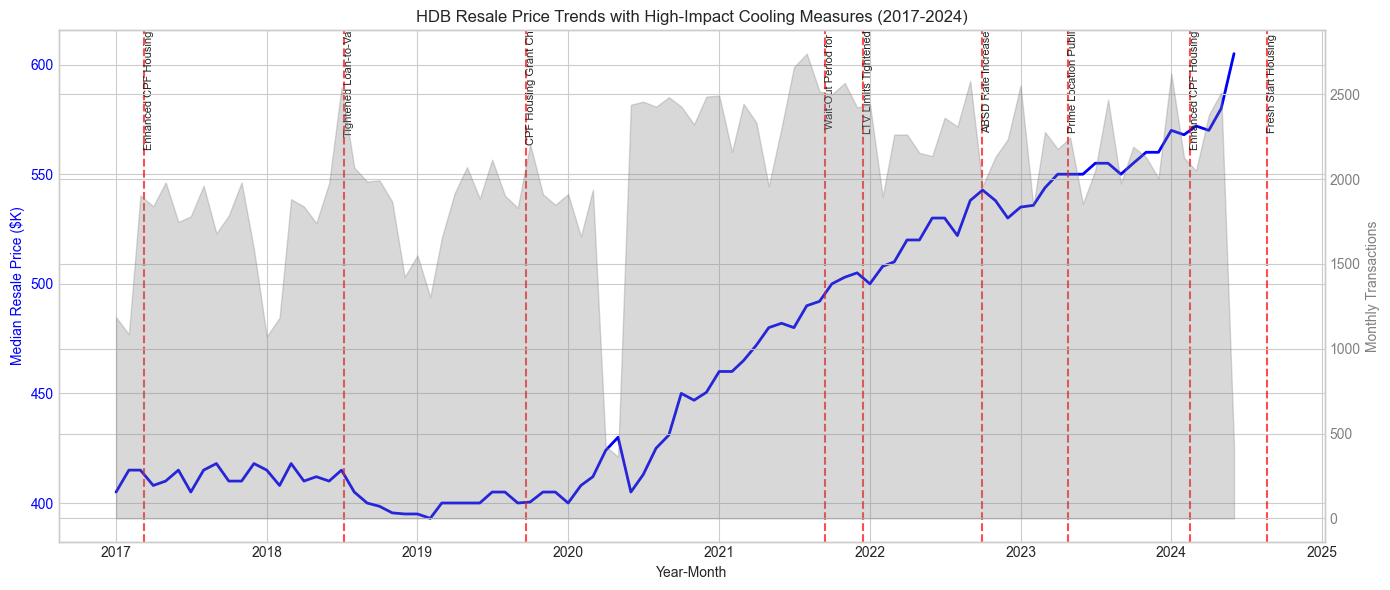


Key Observations:
- Prices showed steady increase from 2017-2021
- Sharp acceleration in 2021-2022 despite cooling measures
- Recent stabilization visible in 2023-2024


In [152]:
# Preliminary Analysis: Monthly median price trends

monthly_prices = df1.groupby('year_month').agg({
    'resale_price': ['median', 'mean', 'count']
}).reset_index()
monthly_prices.columns = ['year_month', 'median_price', 'mean_price', 'transaction_count']
monthly_prices['year_month_dt'] = monthly_prices['year_month'].dt.to_timestamp()

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Price line
ax1.plot(monthly_prices['year_month_dt'], monthly_prices['median_price']/1000,
         'b-', linewidth=2, label='Median Price')
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Median Resale Price ($K)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Add cooling measure markers
for _, row in df5.iterrows():
    ax1.axvline(x=row['date'], color='red', linestyle='--', alpha=0.7)
    ax1.annotate(row['measure_name'][:20], xy=(row['date'], ax1.get_ylim()[1]),
                 rotation=90, fontsize=8, va='top')

# Transaction count on secondary axis
ax2 = ax1.twinx()
ax2.fill_between(monthly_prices['year_month_dt'], monthly_prices['transaction_count'],
                 alpha=0.3, color='gray', label='Transactions')
ax2.set_ylabel('Monthly Transactions', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.title('HDB Resale Price Trends with High-Impact Cooling Measures (2017-2024)')
fig.tight_layout()
plt.show()

print("\nKey Observations:")
print("- Prices showed steady increase from 2017-2021")
print("- Sharp acceleration in 2021-2022 despite cooling measures")
print("- Recent stabilization visible in 2023-2024")

# Presentation of Main Results

*Present the main results of your analysis to stakeholders. Include visualizations and clear interpretations.*

---

**Note**: To be completed for Final Submission.

## Stakeholders

Our analysis targets the following stakeholders:

1. **Prospective HDB Buyers**: Need to understand pricing factors for informed decisions
2. **HDB/Government Policy Makers**: Evaluate effectiveness of cooling measures
3. **Urban Planners**: Understand value impact of amenity placement
4. **Real Estate Analysts**: Market trend insights

# Possible Actions Based on Results (Act)

*Provide a brief description of possible actions to be derived from your data-based insights.*

---

**Note**: To be completed for Final Submission based on analysis findings.

## Preliminary Recommendations

Based on initial data exploration:

**For Home Buyers**:
- Consider timing purchases relative to policy announcements
- Prioritize flats near MRT stations for better value retention
- Monitor SORA trends as they impact mortgage affordability

**For Policy Makers**:
- Evaluate lag effects of cooling measures on prices
- Consider targeted measures for specific market segments

**For Urban Planners**:
- Quantify the price premium of MRT proximity
- Plan amenity distribution for equitable development

# Final Reflection

*Briefly reflect on possible issues or limitations with respect to data ethics and data privacy/security.*

## Considerations on Data Ethics

1. **Algorithmic Fairness**: Our price prediction model must be evaluated for potential biases:
   - Does it systematically under/overvalue certain neighborhoods?
   - Could it perpetuate existing inequalities in housing access?

2. **Housing Affordability Impact**: Publishing accurate price predictions could:
   - Help buyers make informed decisions (positive)
   - Potentially contribute to speculation if misused (negative)

3. **Data Attribution**: All datasets used are properly cited with their original sources and licenses.

4. **Representativeness**: The analysis only covers resale transactions, excluding:
   - BTO (Build-To-Order) flats
   - Rental market
   - Private housing

## Considerations on Data Privacy/Security

1. **PDPA Compliance**:
   - HDB transaction data is aggregated and anonymized
   - No individual buyer/seller information is used
   - Block-level data (not unit-level) maintains privacy

2. **Re-identification Risk**:
   - Combination of block, flat type, and transaction date could theoretically identify transactions
   - We do not attempt to link transactions to individuals

3. **Data Storage**:
   - All data is from public, open-source datasets
   - No sensitive personal information is collected or stored

4. **API Usage**:
   - OneMap API is official government service
   - We comply with rate limits and terms of service

# References

## Data Sources

1. Housing & Development Board. (2024). *Resale flat prices based on registration date from Jan-2017 onwards*. data.gov.sg. https://data.gov.sg/datasets/d_8b84c4ee58e3cfc0ece0d773c8ca6abc/view

2. Lee, Y.X. (2023). *Singapore Train Station Coordinates*. Kaggle. https://www.kaggle.com/datasets/yxlee245/singapore-train-station-coordinates

3. Sharma, S. (2023). *Singapore Malls POIs*. Kaggle. https://www.kaggle.com/datasets/sunnysharma432/singapore-malls-pois

4. Monetary Authority of Singapore. (2024). *Domestic Interest Rates - SORA*. https://eservices.mas.gov.sg/statistics/msb/ExchangeRates.aspx

5. Singapore Land Authority. (2024). *OneMap API*. https://www.onemap.gov.sg/apidocs/

## Policy References

6. Housing & Development Board. (2024). *Cooling Measures and Housing Policies*. https://www.hdb.gov.sg/

7. Ministry of National Development. (2024). *Public Housing Policies*. https://www.mnd.gov.sg/

## Technical References

8. VanderPlas, J. (2023). *Python Data Science Handbook* (2nd ed.). O'Reilly Media.

---

**End of Notebook**

*SC3021 Data Science Fundamentals - AY2025/26 Semester 2*